HYPERPARAMETER TUNING

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

print("--- STARTING GPU-POWERED HYPERPARAMETER TUNING ---")

# 1. Load your optimized dataset
df_final = pd.read_parquet('../data/final/train_hospital_A_optimized.parquet')

# 2. Separate the groups
groups = df_final['Patient_ID']
x = df_final.drop(columns=['SepsisLabel', 'Patient_ID'])
y = df_final['SepsisLabel']

# 3. Calculate imbalance ratio
imbalance_ratio = (y == 0).sum() / (y == 1).sum()
print(f"Dataset Imbalance Ratio: {imbalance_ratio:.2f}")

# 4. Define the Hyperparameter Grid
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# 5. Initialize the base model (WITH GPU ENABLED)
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    eval_metric='aucpr',
    tree_method='hist', 
    device='cuda',       
    random_state=42
)

# 6. Initialize GroupKFold to prevent Data Leakage during cross-validation
gkf = GroupKFold(n_splits=3)

# 7. Set up the Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='average_precision', 
    cv=gkf,              # Using our GroupKFold
    verbose=2,
    random_state=42
)

# 8. Run the search (Passing the groups!)
print("Searching for the optimal hyperparameters...")
random_search.fit(x, y, groups=groups)

print("\n--- TUNING COMPLETE ---")
print("Best Hyperparameters Found:")
for key, value in random_search.best_params_.items():
    print(f"  {key}: {value}")

print(f"\nBest Cross-Validated PR-AUC: {random_search.best_score_:.4f}")

--- STARTING GPU-POWERED HYPERPARAMETER TUNING ---
Dataset Imbalance Ratio: 71.98
Searching for the optimal hyperparameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/home/clopo/ML_Pipeline/venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [22:20:05] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   3.9s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   2.7s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   2.9s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   6.4s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   6.6s
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   6.9s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=100, subsample=0.6; total time=   3.6s
[CV] END colsample_bytree=1.0, learning_rate=0.0

TRAINIG FINAL MODEL

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_recall_curve

print("--- TRAINING FINAL TUNED MODEL ---")

# 1. Load Data
df_final = pd.read_parquet('../data/final/train_hospital_A_optimized.parquet')

groups = df_final['Patient_ID']
x = df_final.drop(columns=['SepsisLabel', 'Patient_ID'])
y = df_final['SepsisLabel']
groups = df_final['Patient_ID']

# 2. GroupShuffleSplit (Preventing Data Leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(x, y, groups))

x_train, x_val = x.iloc[train_idx], x.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

# 3. Calculate Imbalance Ratio for the training set
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 4. Train with Tuned Hyperparameters
print("Training model...")
clf_final = xgb.XGBClassifier(
    max_depth=3,                 # Tuned: Prevents memorizing outliers
    min_child_weight=3,          # Tuned: Demands more evidence per split
    learning_rate=0.05,          
    n_estimators=100,            
    subsample=1.0,               
    colsample_bytree=1.0,        
    scale_pos_weight=imbalance_ratio, # Crucial: Handles class imbalance
    eval_metric='aucpr',
    tree_method='hist',
    device='cuda',               # GPU Acceleration
    random_state=42
)
clf_final.fit(x_train, y_train)

# 5. Evaluate Optimal Threshold
print("Evaluating predictions...")
y_pred_proba = clf_final.predict_proba(x_val)[:, 1]
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_pred_proba)

beta = 2
f2_scores = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-10)

best_idx = np.argmax(f2_scores)

print("\n--- FINAL TUNED RESULTS ---")
print(f"Optimal Probability Threshold: {pr_thresholds[best_idx]:.4f} ({pr_thresholds[best_idx]*100:.1f}%)")
print(f"Max F2-Score: {f2_scores[best_idx]:.4f}")
print(f"Precision:    {precision[best_idx]:.4f} (When the alarm sounds, it is correct {precision[best_idx]*100:.1f}% of the time)")
print(f"Recall:       {recall[best_idx]:.4f} (The alarm catches {recall[best_idx]*100:.1f}% of all actual Sepsis cases)")

--- TRAINING FINAL TUNED MODEL ---
Training model...
Evaluating predictions...

--- FINAL TUNED RESULTS ---
Optimal Probability Threshold: 0.6260 (62.6%)
Max F2-Score: 0.1981
Precision:    0.0641 (When the alarm sounds, it is correct 6.4% of the time)
Recall:       0.4148 (The alarm catches 41.5% of all actual Sepsis cases)


/home/clopo/ML_Pipeline/venv/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:53:22] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Saving final tuned model

In [ ]:
# Save the XGBoost model 
model_path = '../models/tuned_model.json'
clf_final.save_model(model_path)
print(f"Tuned Model saved to: {model_path}")

Tuned Model saved to: ../models/tuned_model.json


Confusion Matrix

--- GENERATING CONFUSION MATRIX ---


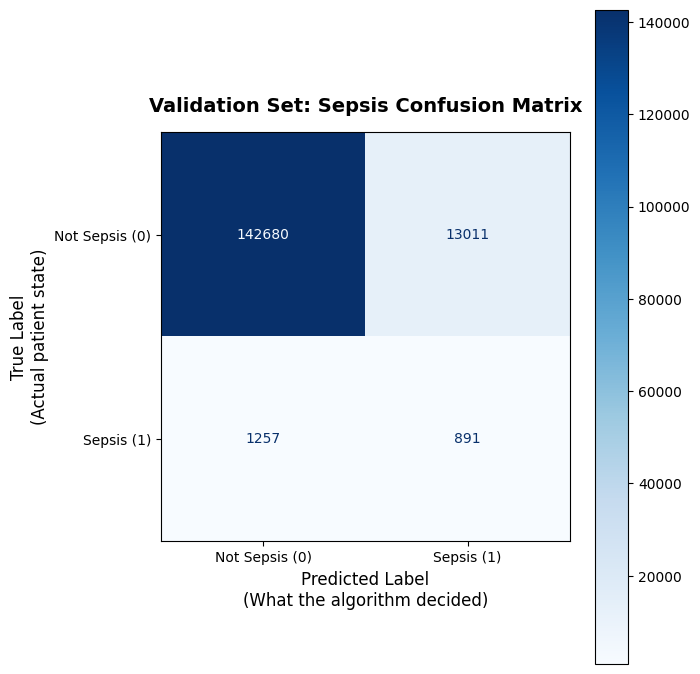

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("--- GENERATING CONFUSION MATRIX ---")

# Use the same optimal threshold selected from the PR/F2 analysis
optimal_threshold = pr_thresholds[best_idx]
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

# 1. Calculate the raw confusion matrix
cm = confusion_matrix(y_val, y_pred_binary)

# 2. Set up the display object with clear clinical labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Not Sepsis (0)', 'Sepsis (1)']
)

# 3. Plot the matrix
fig, ax = plt.subplots(figsize=(7, 7))

disp.plot(cmap='Blues', ax=ax, values_format='d') 

# 4. Add clinical context to the axes
plt.title('Validation Set: Sepsis Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label\n(What the algorithm decided)', fontsize=12)
plt.ylabel('True Label\n(Actual patient state)', fontsize=12)

plt.tight_layout()
plt.show()